# Análise de Sentimentos em E-commerce Brasileiro
Classificação do sentimento (Positivo, Negativo ou Neutro) de avaliações de clientes da Olist, usando NLP e Regressão Logística.

### 1. Carregamento e Exploração dos Dados
Nesta etapa, carrego as avaliações do e-commerce Olist com o Pandas. A base tem 99.224 avaliações, das quais 40.977 têm comentário em texto. Somente essas serão usadas na análise de sentimentos.

In [18]:
import pandas as pd

reviews = pd.read_csv(
    r"D:\Projetos\ecommerce-data-analysis\data\raw\olist_order_reviews_dataset.csv"
)

reviews.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


In [19]:
total = len(reviews)

In [20]:
print(total)

99224


In [21]:
reviews_com_texto = reviews.dropna(subset=['review_comment_message']).copy()

In [22]:
total_com_texto = len(reviews_com_texto)
print(f"Total de avaliações com texto: {total_com_texto}")

Total de avaliações com texto: 40977


In [23]:
import re
import unicodedata
import nltk
from nltk.corpus import stopwords

In [24]:
nltk.download('stopwords')
stopwords_pt = stopwords.words('portuguese')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\bia_o\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [25]:
import unicodedata

In [26]:
def remover_acentos(texto):
    texto_normalizado = unicodedata.normalize('NFD', str(texto))
    return ''.join(c for c in texto_normalizado if unicodedata.category(c) != 'Mn')

In [27]:
remover_acentos("Olá, ótimo teste")

'Ola, otimo teste'

In [28]:
import re

### 2. Pré-processamento de Texto
Para garantir que o algoritmo foque exclusivamente no sentimento real do consumidor, criei uma função de limpeza para remover URLs, acentos, pontuação e palavras de ligação (stopwords). O objetivo é eliminar o ruído da base de dados antes da modelagem.

In [29]:
def limpar_texto(texto):
    texto = str(texto).lower()
    texto = re.sub(r'http\S+', ' ', texto)
    texto = re.sub(r'@\w+', ' ', texto)
    texto = re.sub(r'#', ' ', texto)
    texto = remover_acentos(texto)
    texto = re.sub(r'[^a-z\s]', ' ', texto)
    texto = re.sub(r'\s+', ' ', texto).strip() 
    stops = {remover_acentos(w) for w in stopwords_pt}
    palavras = [w for w in texto.split() if w not in stops and len(w) > 2]

    return ' '.join(palavras)

In [30]:
limpar_texto("Amei a compra! #feliz [https://loja.com](https://loja.com) @vendedor")

'amei compra feliz'

In [31]:
reviews_com_texto['texto_limpo'] = reviews_com_texto['review_comment_message'].apply(limpar_texto)

reviews_com_texto[['review_comment_message', 'texto_limpo']].head()

,review_comment_message,texto_limpo
3,Recebi bem antes do prazo estipulado.,recebi bem antes prazo estipulado
4,Parabéns lojas lannister adorei comprar pela I...,parabens lojas lannister adorei comprar intern...
9,aparelho eficiente. no site a marca do aparelh...,aparelho eficiente site marca aparelho impress...
12,"Mas um pouco ,travando...pelo valor ta Boa.\r\n",pouco travando valor boa
15,"Vendedor confiável, produto ok e entrega antes...",vendedor confiavel produto entrega antes prazo


### Definição do sentimento
O sentimento de cada avaliação foi definido a partir da nota: notas 1 e 2 = Negativo, nota 3 = Neutro e notas 4 e 5 = Positivo. A base é desbalanceada: 26.530 avaliações positivas (65%), 10.890 negativas (27%) e 3.557 neutras (9%).

In [34]:
def classificar_sentimento(nota):
    if nota <= 2:
        return 'Negativo'
    elif nota == 3:
        return 'Neutro'
    else: 
        return 'Positivo'

reviews_com_texto['sentimento'] = reviews_com_texto['review_score'].apply(classificar_sentimento)
print(reviews_com_texto['sentimento'].value_counts())

sentimento
Positivo    26530
Negativo    10890
Neutro       3557
Name: count, dtype: int64


### 3. Vetorização de Texto (TF-IDF)
Conversão do texto limpo em uma matriz numérica de 5.000 atributos para alimentar o modelo de Machine Learning.

In [36]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [38]:
vetorizador = TfidfVectorizer(max_features=5000)
X = vetorizador.fit_transform(reviews_com_texto['texto_limpo'])
y = reviews_com_texto['sentimento']
print(f'Formato da matriz númerica X: {X.shape}')

Formato da matriz númerica X: (40977, 5000)


### 4. Treinamento do Modelo de Machine Learning
Divisão da base em treino (80%) e teste (20%, com 8.196 avaliações) e aplicação da Regressão Logística para prever o sentimento a partir das palavras vetorizadas.

In [39]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

In [40]:
X_treino, X_teste, y_treino, y_teste = train_test_split(X, y, test_size=0.2, random_state=42)
modelo = LogisticRegression(max_iter=1000)
modelo.fit(X_treino, y_treino)
previsoes = modelo.predict(X_teste)
print(classification_report(y_teste, previsoes))

              precision    recall  f1-score   support

    Negativo       0.77      0.86      0.81      2151
      Neutro       0.33      0.06      0.10       730
    Positivo       0.88      0.94      0.91      5315

    accuracy                           0.84      8196
   macro avg       0.66      0.62      0.60      8196
weighted avg       0.80      0.84      0.81      8196



In [42]:
minha_frase = 'Achei o produto incrível, chegou super rápido e bem embalado!'
frase_limpa = limpar_texto(minha_frase)
frase_vetorizada = vetorizador.transform([frase_limpa])
previsao = modelo.predict(frase_vetorizada)
print(f'Sentimento previsto pelo modelo: {previsao[0]}')

Sentimento previsto pelo modelo: Positivo


In [43]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

In [44]:
matriz = confusion_matrix(y_teste, previsoes, labels=['Negativo', 'Neutro', 'Positivo'])

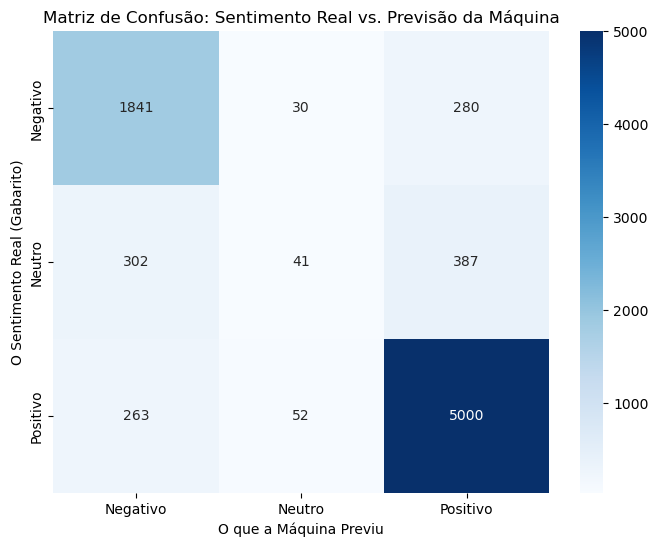

In [45]:
plt.figure(figsize=(8, 6))
sns.heatmap(matriz, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Negativo', 'Neutro', 'Positivo'], 
            yticklabels=['Negativo', 'Neutro', 'Positivo'])

plt.title('Matriz de Confusão: Sentimento Real vs. Previsão da Máquina')
plt.xlabel('O que a Máquina Previu')
plt.ylabel('O Sentimento Real (Gabarito)')
plt.show()

### 5. Conclusão

O modelo de Regressão Logística atingiu 84% de exatidão (accuracy) nos dados de teste. Uma previsão que sempre escolhesse "Positivo" acertaria cerca de 65%.

**Análise da matriz de confusão:**
- **Alta capacidade nos extremos:** avaliações positivas (F1-score de 0,91) e negativas (F1-score de 0,81, com Recall de 0,86).
- **Dificuldade nas avaliações neutras:** apenas 41 acertos entre 730 (Recall de 6%), pois comentários de nota 3 são ambíguos.

**Recomendação de negócio:** adotar uma moderação híbrida, em que o modelo faz a triagem dos extremos (elogios e reclamações graves) e as avaliações neutras seguem para análise humana.